# Upgrade Modelo 1: Pronóstico de Demanda (Avanzado)
En este notebook entrenaremos modelos avanzados de series temporales (XGBoost Regressor, SARIMAX, Prophet y Ridge Regressor) para pronosticar la demanda logística de 3 medicamentos a 7, 14 y 60 días.
Utilizamos datos históricos combinados con **variables exógenas del censo poblacional de riesgo** y **features a largo plazo**.

In [91]:
# Instalación de dependencias (Descomentar si es necesario)
# !pip install xgboost statsmodels prophet scikit-learn

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import itertools
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import statsmodels.api as sm
from prophet import Prophet
from sklearn.linear_model import Ridge
import joblib

warnings.filterwarnings('ignore')

## 1. Preparación de Datos (Data Preparation)

In [93]:
BASE_DIR = Path(".").resolve().parent
DATA_PATH = BASE_DIR / "datos" / "datos_modelo1" / "raw" / "aldimi_demand_avanzado.csv"

df = pd.read_csv(DATA_PATH)
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)
print(f"Dataset cargado con {len(df)} registros. Desde {df['fecha'].min().date()} hasta {df['fecha'].max().date()}")

def preparar_datos_horizonte(df, drug, h):
    df_h = df.copy()
    
    # Target Acumulado
    target_col = f'{drug}_demand'
    df_h['target'] = df_h[target_col].rolling(window=h).sum().shift(-h)
    
    # Features Lags Corto y Largo Plazo
    df_h['demanda_hoy'] = df_h[target_col]
    df_h['promedio_semanal'] = df_h[target_col].rolling(window=7).mean()
    df_h['promedio_mensual'] = df_h[target_col].rolling(window=30).mean()
    df_h['promedio_trimestral'] = df_h[target_col].rolling(window=90).mean()
    df_h['lag_365'] = df_h[target_col].shift(365)
    
    df_h = df_h.dropna().copy()
    
    features = ['n_low', 'n_medium', 'n_high', 'dia_semana', 'es_fin_de_semana', 
                'demanda_hoy', 'promedio_semanal', 'promedio_mensual', 'promedio_trimestral', 'lag_365']
    
    #70% Train, 15% Val, 15% Test
    n = len(df_h)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)
    
    train = df_h.iloc[:train_end]
    val = df_h.iloc[train_end:val_end]
    test = df_h.iloc[val_end:]
    
    return train, val, test, features

Dataset cargado con 2106 registros. Desde 2014-01-02 hasta 2019-10-08


## 2. Funciones de Modelado y Tuning

In [94]:
def evaluate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

def train_tune_xgboost(train, val, features):
    best_rmse = float('inf')
    best_model = None
    best_params = None
    
    for n_est in [10, 15, 25, 35, 40, 50, 75, 100]:
        for lr in [ 0.03, 0.04, 0.05, 0.06, 0.07, 0.1, 0.15, 0.2, 0.25]:
            for md in [2, 3, 4, 5]:
                model = XGBRegressor(n_estimators=n_est, learning_rate=lr, max_depth=md, random_state=42)
                model.fit(train[features], train['target'])
                preds = model.predict(val[features])
                rmse = np.sqrt(mean_squared_error(val['target'], preds))
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_model = model
                    best_params = {'n_est': n_est, 'lr': lr, 'max_depth': md}
    return best_model, best_params

def train_tune_sarimax(train, val, features):
    best_rmse = float('inf')
    best_model_results = None
    best_order = None
    
    p = d = q = [0, 1]
    pdq = list(itertools.product(p, d, q))
    
    exog_train = train[features]
    exog_val = val[features]
    
    for param in pdq:
        try:
            model = sm.tsa.SARIMAX(train['target'].values, exog=exog_train.values, order=param, enforce_stationarity=False, enforce_invertibility=False)
            results = model.fit(disp=False)
            preds = results.forecast(steps=len(val), exog=exog_val.values)
            rmse = np.sqrt(mean_squared_error(val['target'], preds))
            
            if rmse < best_rmse:
                best_rmse = rmse
                best_model_results = results
                best_order = param
        except:
            continue
    return best_model_results, best_order

def train_tune_prophet(train, val, features):
    df_prophet_train = train[['fecha', 'target'] + features].rename(columns={'fecha': 'ds', 'target': 'y'})
    df_prophet_val = val[['fecha'] + features].rename(columns={'fecha': 'ds'})
    
    best_rmse = float('inf')
    best_model = None
    best_params = None
    
    for changepoint in [0.05, 0.1]:
        m = Prophet(changepoint_prior_scale=changepoint)
        for f in features:
            m.add_regressor(f)
        
        m.fit(df_prophet_train)
        forecast = m.predict(df_prophet_val)
        preds = forecast['yhat'].values
        rmse = np.sqrt(mean_squared_error(val['target'], preds))
        
        if rmse < best_rmse:
            best_rmse = rmse
            best_model = m
            best_params = {'changepoint': changepoint}
            
    return best_model, best_params

def train_tune_ridge(train, val, features):
    best_rmse = float('inf')
    best_model = None
    best_params = None
    
    y_train = train['target'].values
    
    alphas = [0.1, 1.0, 10.0, 100.0, 1000.0]
    for a in alphas:
        model = Ridge(alpha=a)
        model.fit(train[features], y_train)
        preds = model.predict(val[features])
        rmse = np.sqrt(mean_squared_error(val['target'], preds))
        
        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model
            best_params = {'alpha': a}
            
    return best_model, best_params

## Definición de Iteraciones

In [95]:
drugs = ['N02BE', 'N05B', 'M01AB']
horizons = [7, 14, 60]

## 3. Tuning de XGBoost

In [96]:
xgb_results = {}
for drug in drugs:
    for h in horizons:
        print(f"Entrenando XGBoost para {drug} a {h} días...")
        train, val, test, features = preparar_datos_horizonte(df, drug, h)
        model, params = train_tune_xgboost(train, val, features)
        preds = model.predict(val[features])
        metrics = evaluate_metrics(val['target'], preds, "XGBoost")
        metrics['Params'] = str(params)
        xgb_results[(drug, h)] = {'model': model, 'metrics': metrics}

print("\nTuning de XGBoost completado. Mejores métricas por iteración:")
xgb_summary = pd.DataFrame([ {**{'Drug': d, 'Horizon': h}, **v['metrics']} for (d, h), v in xgb_results.items() ])
display(xgb_summary)

Entrenando XGBoost para N02BE a 7 días...
Entrenando XGBoost para N02BE a 14 días...
Entrenando XGBoost para N02BE a 60 días...
Entrenando XGBoost para N05B a 7 días...
Entrenando XGBoost para N05B a 14 días...
Entrenando XGBoost para N05B a 60 días...
Entrenando XGBoost para M01AB a 7 días...
Entrenando XGBoost para M01AB a 14 días...
Entrenando XGBoost para M01AB a 60 días...

Tuning de XGBoost completado. Mejores métricas por iteración:


,Drug,Horizon,Model,MAE,MSE,RMSE,R2,Params
0,N02BE,7,XGBoost,120.109623,2.301434e+04,151.704781,0.810026,"{'n_est': 40, 'lr': 0.1, 'max_depth': 2}"
1,N02BE,14,XGBoost,218.998838,7.988222e+04,282.634429,0.818442,"{'n_est': 40, 'lr': 0.2, 'max_depth': 2}"
2,N02BE,60,XGBoost,1039.376887,1.569424e+06,1252.766506,0.740618,"{'n_est': 100, 'lr': 0.15, 'max_depth': 5}"
3,N05B,7,XGBoost,22.746164,7.798245e+02,27.925339,-0.060506,"{'n_est': 25, 'lr': 0.07, 'max_depth': 2}"
4,N05B,14,XGBoost,38.870438,2.451374e+03,49.511356,-0.732924,"{'n_est': 10, 'lr': 0.15, 'max_depth': 2}"
5,N05B,60,XGBoost,182.650048,3.816585e+04,195.360814,-5.589043,"{'n_est': 15, 'lr': 0.07, 'max_depth': 2}"
6,M01AB,7,XGBoost,18.325603,5.291949e+02,23.004236,0.444424,"{'n_est': 10, 'lr': 0.25, 'max_depth': 2}"
7,M01AB,14,XGBoost,35.549181,1.919070e+03,43.807194,0.316527,"{'n_est': 35, 'lr': 0.05, 'max_depth': 2}"
8,M01AB,60,XGBoost,86.498541,1.047197e+04,102.332657,0.070055,"{'n_est': 10, 'lr': 0.2, 'max_depth': 2}"


## 4. Tuning de SARIMAX

In [97]:
sarimax_results = {}
for drug in drugs:
    for h in horizons:
        print(f"Entrenando SARIMAX para {drug} a {h} días...")
        train, val, test, features = preparar_datos_horizonte(df, drug, h)
        model, order = train_tune_sarimax(train, val, features)
        preds = model.forecast(steps=len(val), exog=val[features].values)
        metrics = evaluate_metrics(val['target'], preds, "SARIMAX")
        metrics['Params'] = f"order={order}"
        sarimax_results[(drug, h)] = {'model': model, 'metrics': metrics}

print("\nTuning de SARIMAX completado. Mejores métricas por iteración:")
sarimax_summary = pd.DataFrame([ {**{'Drug': d, 'Horizon': h}, **v['metrics']} for (d, h), v in sarimax_results.items() ])
display(sarimax_summary)

Entrenando SARIMAX para N02BE a 7 días...
Entrenando SARIMAX para N02BE a 14 días...
Entrenando SARIMAX para N02BE a 60 días...
Entrenando SARIMAX para N05B a 7 días...
Entrenando SARIMAX para N05B a 14 días...
Entrenando SARIMAX para N05B a 60 días...
Entrenando SARIMAX para M01AB a 7 días...
Entrenando SARIMAX para M01AB a 14 días...
Entrenando SARIMAX para M01AB a 60 días...

Tuning de SARIMAX completado. Mejores métricas por iteración:


,Drug,Horizon,Model,MAE,MSE,RMSE,R2,Params
0,N02BE,7,SARIMAX,118.367832,2.366171e+04,153.823620,0.804682,"order=(0, 0, 0)"
1,N02BE,14,SARIMAX,249.142479,9.881295e+04,314.345279,0.775416,"order=(0, 0, 0)"
2,N02BE,60,SARIMAX,1392.726436,2.820711e+06,1679.497325,0.533816,"order=(0, 0, 0)"
3,N05B,7,SARIMAX,22.476353,7.437351e+02,27.271507,-0.011427,"order=(0, 0, 0)"
4,N05B,14,SARIMAX,37.025095,2.027213e+03,45.024583,-0.433076,"order=(1, 1, 0)"
5,N05B,60,SARIMAX,66.377106,6.031786e+03,77.664573,-0.041342,"order=(0, 1, 0)"
6,M01AB,7,SARIMAX,18.511500,5.332682e+02,23.092602,0.440148,"order=(0, 0, 0)"
7,M01AB,14,SARIMAX,34.640793,1.911978e+03,43.726170,0.319053,"order=(0, 0, 0)"
8,M01AB,60,SARIMAX,78.079135,9.292914e+03,96.399761,0.174759,"order=(0, 1, 0)"


## 5. Tuning de Prophet

In [98]:
prophet_results = {}
for drug in drugs:
    for h in horizons:
        print(f"Entrenando Prophet para {drug} a {h} días...")
        train, val, test, features = preparar_datos_horizonte(df, drug, h)
        model, params = train_tune_prophet(train, val, features)
        df_prophet_val = val[['fecha'] + features].rename(columns={'fecha': 'ds'})
        preds = model.predict(df_prophet_val)['yhat'].values
        metrics = evaluate_metrics(val['target'], preds, "Prophet")
        metrics['Params'] = str(params)
        prophet_results[(drug, h)] = {'model': model, 'metrics': metrics}

print("\nTuning de Prophet completado. Mejores métricas por iteración:")
prophet_summary = pd.DataFrame([ {**{'Drug': d, 'Horizon': h}, **v['metrics']} for (d, h), v in prophet_results.items() ])
display(prophet_summary)

Entrenando Prophet para N02BE a 7 días...


15:12:51 - cmdstanpy - INFO - Chain [1] start processing
15:12:51 - cmdstanpy - INFO - Chain [1] done processing
15:12:52 - cmdstanpy - INFO - Chain [1] start processing
15:12:52 - cmdstanpy - INFO - Chain [1] done processing


Entrenando Prophet para N02BE a 14 días...


15:12:53 - cmdstanpy - INFO - Chain [1] start processing
15:12:53 - cmdstanpy - INFO - Chain [1] done processing
15:12:53 - cmdstanpy - INFO - Chain [1] start processing
15:12:54 - cmdstanpy - INFO - Chain [1] done processing


Entrenando Prophet para N02BE a 60 días...


...

15:13:06 - cmdstanpy - INFO - Chain [1] start processing
15:13:06 - cmdstanpy - INFO - Chain [1] done processing
15:13:06 - cmdstanpy - INFO - Chain [1] start processing
15:13:07 - cmdstanpy - INFO - Chain [1] done processing


Entrenando Prophet para M01AB a 60 días...


15:13:07 - cmdstanpy - INFO - Chain [1] start processing
15:13:08 - cmdstanpy - INFO - Chain [1] done processing
15:13:08 - cmdstanpy - INFO - Chain [1] start processing
15:13:10 - cmdstanpy - INFO - Chain [1] done processing



Tuning de Prophet completado. Mejores métricas por iteración:


,Drug,Horizon,Model,MAE,MSE,RMSE,R2,Params
0,N02BE,7,Prophet,115.360263,20574.524575,143.438226,0.830165,{'changepoint': 0.05}
1,N02BE,14,Prophet,274.649215,102887.201315,320.760349,0.766156,{'changepoint': 0.1}
2,N02BE,60,Prophet,444.724816,268039.742406,517.725547,0.955701,{'changepoint': 0.1}
3,N05B,7,Prophet,21.148167,663.976956,25.767750,0.097038,{'changepoint': 0.05}
4,N05B,14,Prophet,41.426362,2759.046208,52.526624,-0.950423,{'changepoint': 0.05}
5,N05B,60,Prophet,296.010953,113718.862675,337.222275,-18.632695,{'changepoint': 0.1}
6,M01AB,7,Prophet,19.915489,697.336227,26.407125,0.267901,{'changepoint': 0.05}
7,M01AB,14,Prophet,39.363493,2636.162967,51.343578,0.061136,{'changepoint': 0.1}
8,M01AB,60,Prophet,190.895303,56252.668503,237.176450,-3.995421,{'changepoint': 0.05}


## 6. Tuning de Ridge Regressor

In [99]:
ridge_results = {}
for drug in drugs:
    for h in horizons:
        print(f"Entrenando Ridge Regressor para {drug} a {h} días...")
        train, val, test, features = preparar_datos_horizonte(df, drug, h)
        model, params = train_tune_ridge(train, val, features)
        preds = model.predict(val[features])
        metrics = evaluate_metrics(val['target'], preds, "Ridge")
        metrics['Params'] = str(params)
        ridge_results[(drug, h)] = {'model': model, 'metrics': metrics}

print("\nTuning de Ridge Regressor completado. Mejores métricas por iteración:")
ridge_summary = pd.DataFrame([ {**{'Drug': d, 'Horizon': h}, **v['metrics']} for (d, h), v in ridge_results.items() ])
display(ridge_summary)

Entrenando Ridge Regressor para N02BE a 7 días...
Entrenando Ridge Regressor para N02BE a 14 días...
Entrenando Ridge Regressor para N02BE a 60 días...
Entrenando Ridge Regressor para N05B a 7 días...
Entrenando Ridge Regressor para N05B a 14 días...
Entrenando Ridge Regressor para N05B a 60 días...
Entrenando Ridge Regressor para M01AB a 7 días...
Entrenando Ridge Regressor para M01AB a 14 días...
Entrenando Ridge Regressor para M01AB a 60 días...

Tuning de Ridge Regressor completado. Mejores métricas por iteración:


,Drug,Horizon,Model,MAE,MSE,RMSE,R2,Params
0,N02BE,7,Ridge,118.318317,2.363525e+04,153.737593,0.804900,{'alpha': 1000.0}
1,N02BE,14,Ridge,248.288505,9.797294e+04,313.006299,0.777325,{'alpha': 1000.0}
2,N02BE,60,Ridge,1372.758809,2.671877e+06,1634.587632,0.558414,{'alpha': 1000.0}
3,N05B,7,Ridge,22.422148,7.430679e+02,27.259271,-0.010520,{'alpha': 1000.0}
4,N05B,14,Ridge,40.741982,2.480538e+03,49.804997,-0.753540,{'alpha': 1000.0}
5,N05B,60,Ridge,227.148496,6.247742e+04,249.954843,-9.786251,{'alpha': 1000.0}
6,M01AB,7,Ridge,18.218324,5.062973e+02,22.501052,0.468463,{'alpha': 1000.0}
7,M01AB,14,Ridge,34.509993,1.811185e+03,42.558015,0.354951,{'alpha': 1000.0}
8,M01AB,60,Ridge,114.202076,1.773171e+04,133.160478,-0.574634,{'alpha': 1000.0}


## 7. Selección Final y Prueba (Test Set)
Comparamos las 4 variantes, seleccionamos al ganador y medimos su error final en los datos no vistos.


Resultados Finales para N02BE a 7 días


,Model,MAE,MSE,RMSE,R2,Params
0,XGBoost,120.109623,23014.340427,151.704781,0.810026,"{'n_est': 40, 'lr': 0.1, 'max_depth': 2}"
1,SARIMAX,118.367832,23661.705925,153.823620,0.804682,"order=(0, 0, 0)"
2,Prophet,115.360263,20574.524575,143.438226,0.830165,{'changepoint': 0.05}
3,Ridge,118.318317,23635.247576,153.737593,0.804900,{'alpha': 1000.0}


Seleccionando: Prophet


,Model,MAE,MSE,RMSE,R2
0,TEST Prophet,155.406303,33234.559328,182.303481,0.765973


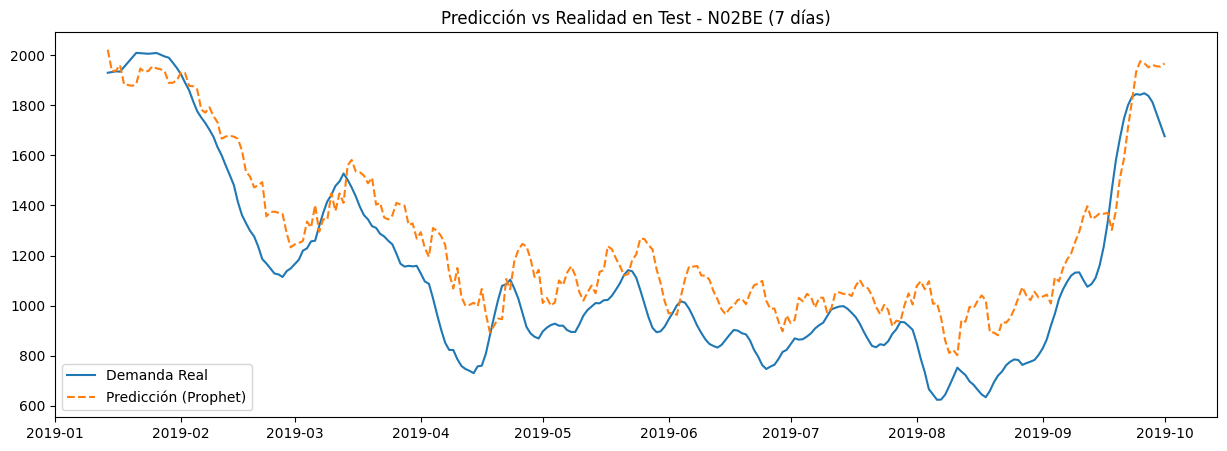

Modelo exportado correctamente en /modelos/modelosfinales

Resultados Finales para N02BE a 14 días


,Model,MAE,MSE,RMSE,R2,Params
0,XGBoost,218.998838,79882.220720,282.634429,0.818442,"{'n_est': 40, 'lr': 0.2, 'max_depth': 2}"
1,SARIMAX,249.142479,98812.954720,314.345279,0.775416,"order=(0, 0, 0)"
2,Prophet,274.649215,102887.201315,320.760349,0.766156,{'changepoint': 0.1}
3,Ridge,248.288505,97972.943270,313.006299,0.777325,{'alpha': 1000.0}


Seleccionando: XGBoost


,Model,MAE,MSE,RMSE,R2
0,TEST XGBoost,296.935874,137230.984736,370.447007,0.744771


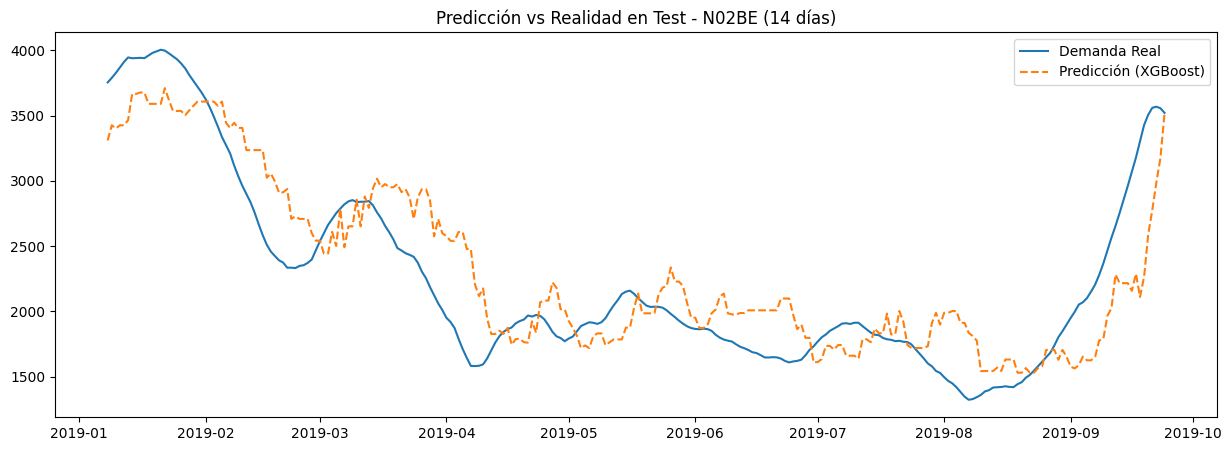

Modelo exportado correctamente en /modelos/modelosfinales

Resultados Finales para N02BE a 60 días


,Model,MAE,MSE,RMSE,R2,Params
0,XGBoost,1039.376887,1.569424e+06,1252.766506,0.740618,"{'n_est': 100, 'lr': 0.15, 'max_depth': 5}"
1,SARIMAX,1392.726436,2.820711e+06,1679.497325,0.533816,"order=(0, 0, 0)"
2,Prophet,444.724816,2.680397e+05,517.725547,0.955701,{'changepoint': 0.1}
3,Ridge,1372.758809,2.671877e+06,1634.587632,0.558414,{'alpha': 1000.0}


Seleccionando: Prophet


,Model,MAE,MSE,RMSE,R2
0,TEST Prophet,2556.751086,7.527033e+06,2743.543822,0.07269


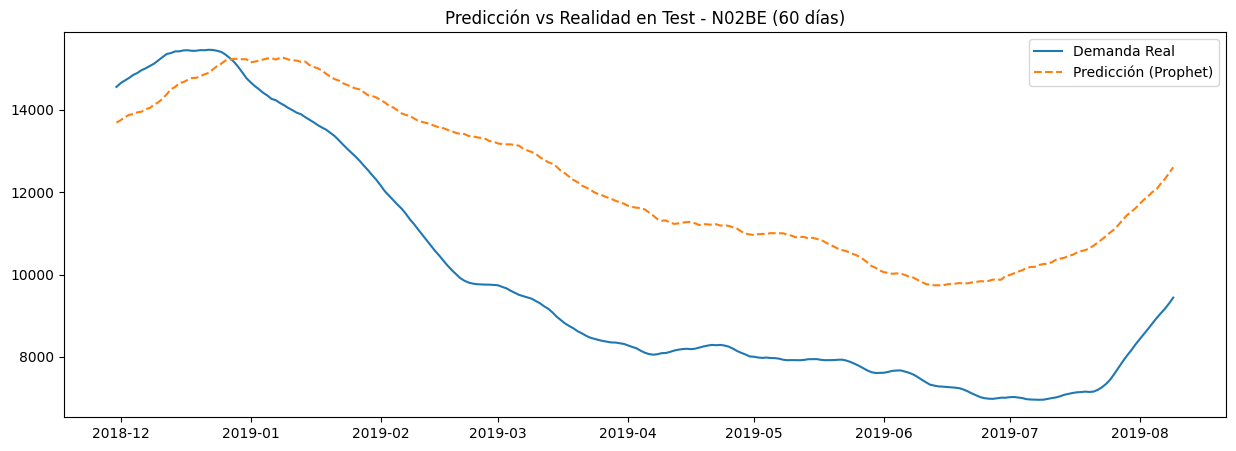

Modelo exportado correctamente en /modelos/modelosfinales

Resultados Finales para N05B a 7 días


,Model,MAE,MSE,RMSE,R2,Params
0,XGBoost,22.746164,779.824548,27.925339,-0.060506,"{'n_est': 25, 'lr': 0.07, 'max_depth': 2}"
1,SARIMAX,22.476353,743.735079,27.271507,-0.011427,"order=(0, 0, 0)"
2,Prophet,21.148167,663.976956,25.767750,0.097038,{'changepoint': 0.05}
3,Ridge,22.422148,743.067852,27.259271,-0.010520,{'alpha': 1000.0}


Seleccionando: Prophet


,Model,MAE,MSE,RMSE,R2
0,TEST Prophet,23.624987,791.020387,28.125085,-0.141613


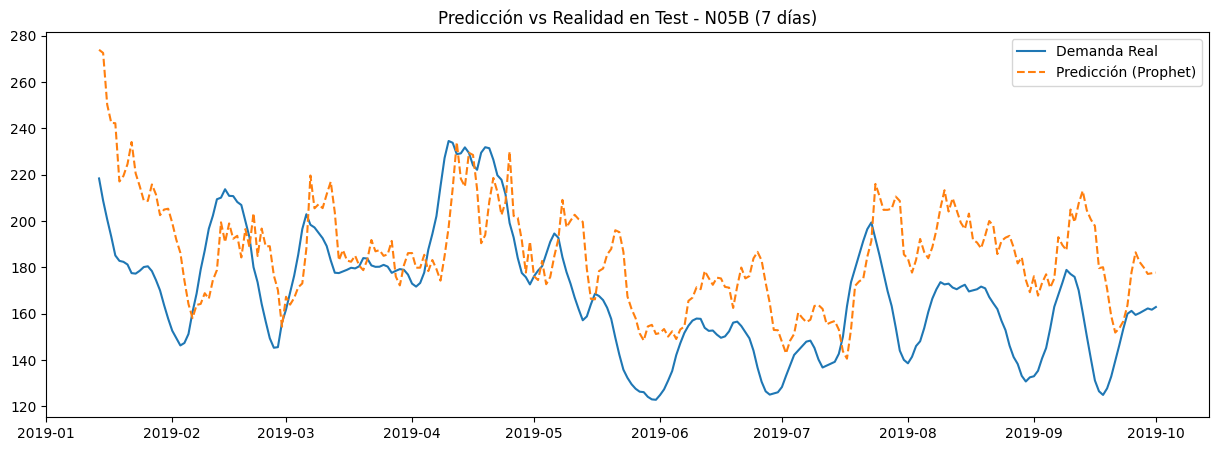

Modelo exportado correctamente en /modelos/modelosfinales

Resultados Finales para N05B a 14 días


,Model,MAE,MSE,RMSE,R2,Params
0,XGBoost,38.870438,2451.374414,49.511356,-0.732924,"{'n_est': 10, 'lr': 0.15, 'max_depth': 2}"
1,SARIMAX,37.025095,2027.213118,45.024583,-0.433076,"order=(1, 1, 0)"
2,Prophet,41.426362,2759.046208,52.526624,-0.950423,{'changepoint': 0.05}
3,Ridge,40.741982,2480.537709,49.804997,-0.753540,{'alpha': 1000.0}


Seleccionando: SARIMAX


,Model,MAE,MSE,RMSE,R2
0,TEST SARIMAX,120.340985,21364.968489,146.167604,-8.381791


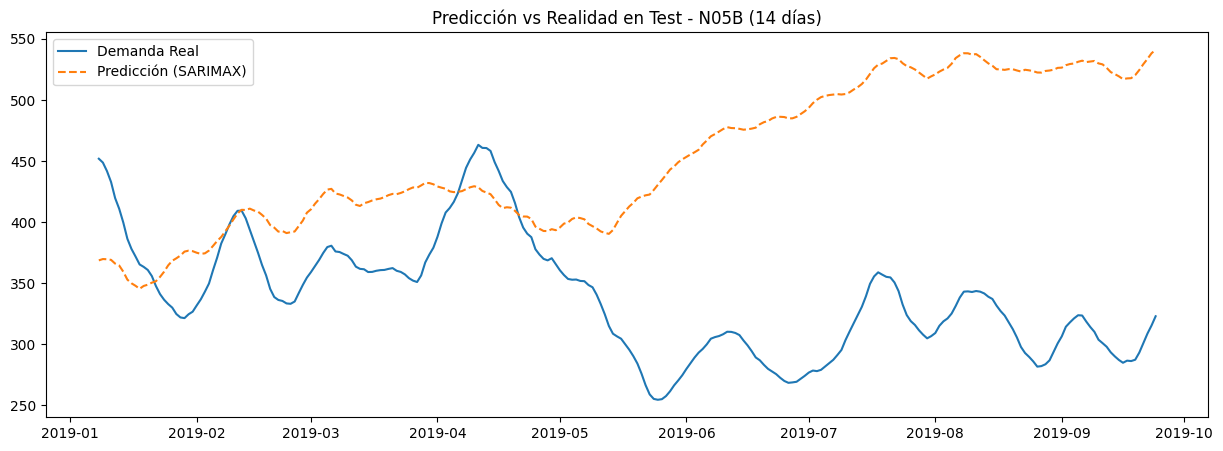

Modelo exportado correctamente en /modelos/modelosfinales

Resultados Finales para N05B a 60 días


,Model,MAE,MSE,RMSE,R2,Params
0,XGBoost,182.650048,38165.847658,195.360814,-5.589043,"{'n_est': 15, 'lr': 0.07, 'max_depth': 2}"
1,SARIMAX,66.377106,6031.785910,77.664573,-0.041342,"order=(0, 1, 0)"
2,Prophet,296.010953,113718.862675,337.222275,-18.632695,{'changepoint': 0.1}
3,Ridge,227.148496,62477.423576,249.954843,-9.786251,{'alpha': 1000.0}


Seleccionando: SARIMAX


,Model,MAE,MSE,RMSE,R2
0,TEST SARIMAX,296.145393,122037.008293,349.337957,-4.314915


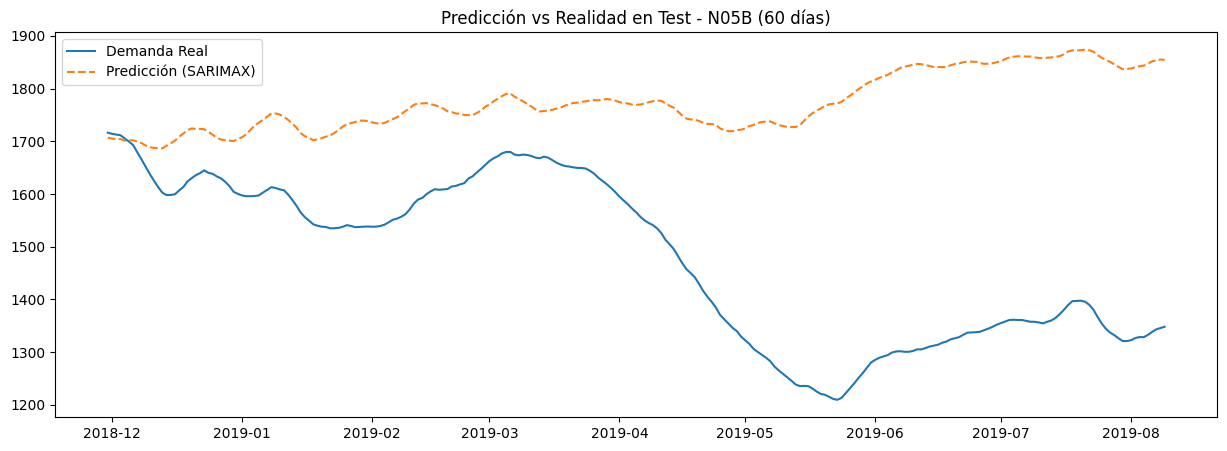

Modelo exportado correctamente en /modelos/modelosfinales

Resultados Finales para M01AB a 7 días


,Model,MAE,MSE,RMSE,R2,Params
0,XGBoost,18.325603,529.194876,23.004236,0.444424,"{'n_est': 10, 'lr': 0.25, 'max_depth': 2}"
1,SARIMAX,18.511500,533.268249,23.092602,0.440148,"order=(0, 0, 0)"
2,Prophet,19.915489,697.336227,26.407125,0.267901,{'changepoint': 0.05}
3,Ridge,18.218324,506.297325,22.501052,0.468463,{'alpha': 1000.0}


Seleccionando: Ridge


,Model,MAE,MSE,RMSE,R2
0,TEST Ridge,14.721487,343.830383,18.542664,0.448504


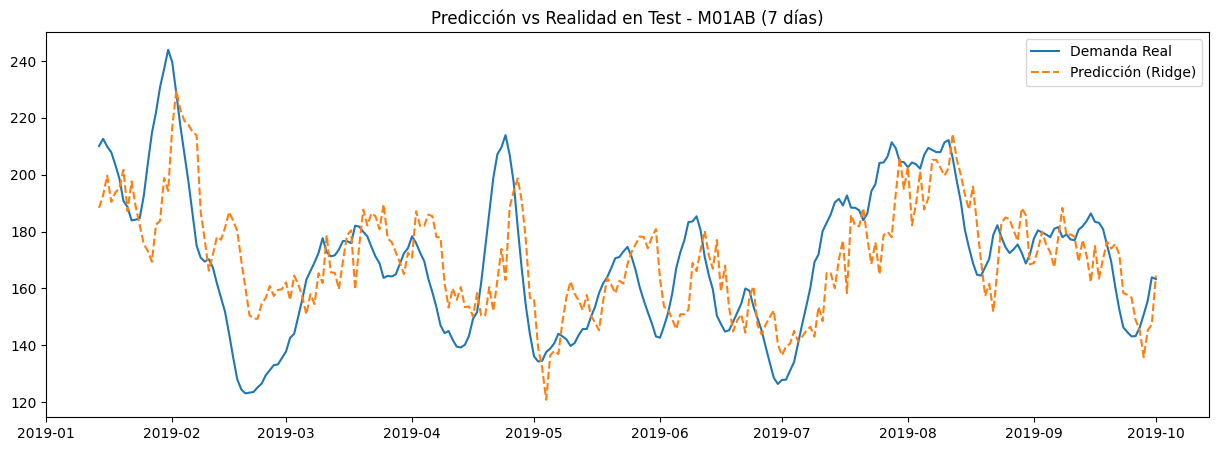

Modelo exportado correctamente en /modelos/modelosfinales

Resultados Finales para M01AB a 14 días


,Model,MAE,MSE,RMSE,R2,Params
0,XGBoost,35.549181,1919.070270,43.807194,0.316527,"{'n_est': 35, 'lr': 0.05, 'max_depth': 2}"
1,SARIMAX,34.640793,1911.977956,43.726170,0.319053,"order=(0, 0, 0)"
2,Prophet,39.363493,2636.162967,51.343578,0.061136,{'changepoint': 0.1}
3,Ridge,34.509993,1811.184615,42.558015,0.354951,{'alpha': 1000.0}


Seleccionando: Ridge


,Model,MAE,MSE,RMSE,R2
0,TEST Ridge,31.161443,1486.592819,38.556359,0.187337


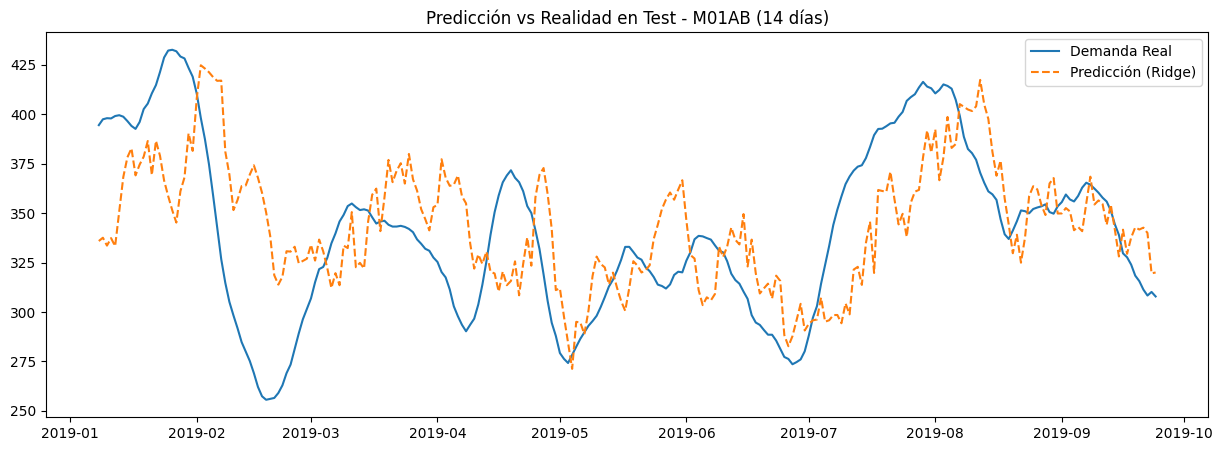

Modelo exportado correctamente en /modelos/modelosfinales

Resultados Finales para M01AB a 60 días


,Model,MAE,MSE,RMSE,R2,Params
0,XGBoost,86.498541,10471.972624,102.332657,0.070055,"{'n_est': 10, 'lr': 0.2, 'max_depth': 2}"
1,SARIMAX,78.079135,9292.913979,96.399761,0.174759,"order=(0, 1, 0)"
2,Prophet,190.895303,56252.668503,237.176450,-3.995421,{'changepoint': 0.05}
3,Ridge,114.202076,17731.712923,133.160478,-0.574634,{'alpha': 1000.0}


Seleccionando: SARIMAX


,Model,MAE,MSE,RMSE,R2
0,TEST SARIMAX,254.203614,81457.454739,285.407524,-6.049831


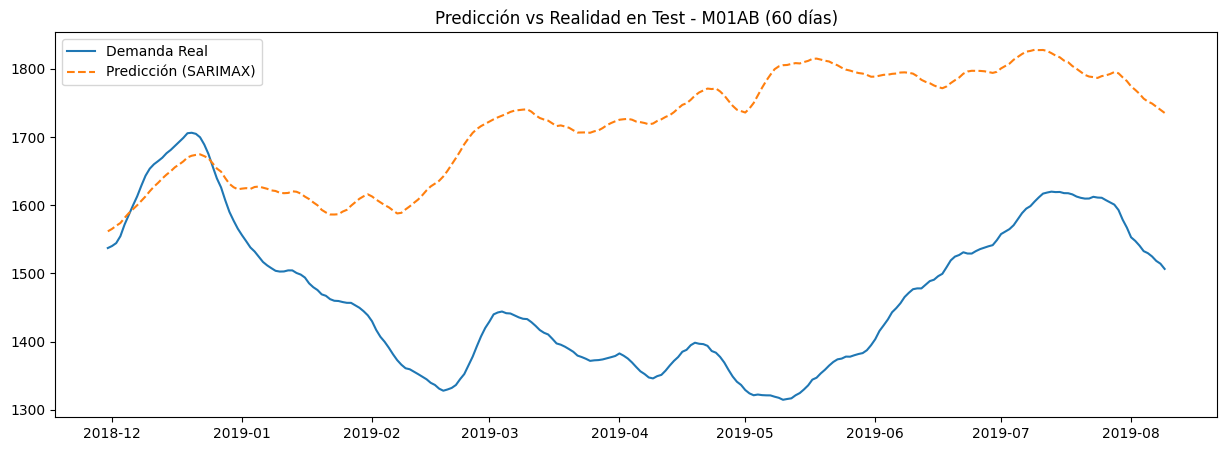

Modelo exportado correctamente en /modelos/modelosfinales


In [100]:
os.makedirs('../modelos', exist_ok=True)

for drug in drugs:
    for h in horizons:
        print(f"\n{'='*50}")
        print(f"Resultados Finales para {drug} a {h} días")
        print(f"{'='*50}")
        
        # Juntar métricas
        xgb_m = xgb_results[(drug, h)]['metrics']
        sarimax_m = sarimax_results[(drug, h)]['metrics']
        prophet_m = prophet_results[(drug, h)]['metrics']
        ridge_m = ridge_results[(drug, h)]['metrics']
        
        metrics_df = pd.DataFrame([xgb_m, sarimax_m, prophet_m, ridge_m])
        display(metrics_df)
        
        # Seleccionar el mejor
        best_model_name = metrics_df.loc[metrics_df['RMSE'].idxmin()]['Model']
        print(f"Seleccionando: {best_model_name}")
        
        train, val, test, features = preparar_datos_horizonte(df, drug, h)
        
        # Predecir en Test
        if best_model_name == "XGBoost":
            final_model = xgb_results[(drug, h)]['model']
            test_preds = final_model.predict(test[features])
        elif best_model_name == "SARIMAX":
            final_model = sarimax_results[(drug, h)]['model']
            test_preds = final_model.forecast(steps=len(test), exog=test[features].values)
        elif best_model_name == "Prophet":
            final_model = prophet_results[(drug, h)]['model']
            df_prophet_test = test[['fecha'] + features].rename(columns={'fecha': 'ds'})
            test_preds = final_model.predict(df_prophet_test)['yhat'].values
        else: 
            final_model = ridge_results[(drug, h)]['model']
            test_preds = final_model.predict(test[features])
            
        test_metrics = evaluate_metrics(test['target'], test_preds, f"TEST {best_model_name}")
        display(pd.DataFrame([test_metrics]))
        
        # Gráfica
        plt.figure(figsize=(15, 5))
        plt.plot(test['fecha'], test['target'], label='Demanda Real')
        plt.plot(test['fecha'], test_preds, label=f'Predicción ({best_model_name})', linestyle='--')
        plt.title(f'Predicción vs Realidad en Test - {drug} ({h} días)')
        plt.legend()
        plt.show()
        
        # Exportar modelo
        model_path = f"../modelos/modelosfinales/modelo1_demanda_{drug}_{h}dias_avanzado.joblib"
        if best_model_name != "Prophet":
            joblib.dump(final_model, model_path)
        else:
            import json
            from prophet.serialize import model_to_json
            with open(f"../modelos/modelosfinales/modelo1_demanda_{drug}_{h}dias_avanzado.json", 'w') as fout:
                json.dump(model_to_json(final_model), fout)
        print(f"Modelo exportado correctamente en /modelos/modelosfinales")
